## **Analisis Exploratorio**
### **Desigualdad Educativa en Chile:** Análisis de Resultados PAES por Tipo de Establecimiento

#### **Nombres:** Lucas Chicao - Ninoska Cid - Isidora Gomez

#### **Curso**: IMT-2200 - Introduccion a la Ciencias de Datos

___
### **Contexto del proyecto:** 
La PAES es la prueba que miles de estudiantes chilenos rinden para acceder a la universidad, pero es un hecho que no todos cuentan con las mismas oportunidades educativas, ya que estas dependen del tipo de colegio en el que estudiaron.

En este proyecto, nos proponemos investigar si efectivamente hay diferencias en los puntajes de la PAES entre estudiantes de colegios públicos, subvencionados y privados, y también medir la magnitud de esas posibles diferencias.


### **Datos a usar:**
Los datos que usaremos en nuestro proyecto seran principalmente de base de datos de:

-DEMRE

-chiquillos si les parece aqui hay una base de datos para poder usar, si lo usamos eliminen este mensajito: https://www.kaggle.com/datasets/daniellopez01/admisionuescl

### **Analisis Exploratorio:**
En las siguientes lineas exploraremos los datos que ya obtuvimos y revisaremos como vamos en relacion con datos.
 

In [1]:
#LIBRERIAS A USAR
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
#...

# Analisis Exploratorio de la base de datos del DEMRE (2023 - 2025)

La bdd del demre viene con 4 tipos de archivos segun el año

    - Inscripcion   

    - Matricula

    - Postulacion

    - Rendicion

Cada uno de estos tipo de archivos tienen distinto formato

In [3]:
#CARGAR DATOS Y DF (INSCRIPCION)



base_path = os.path.dirname(os.getcwd())  # Esto sube un nivel desde 'Análisis Exploratorio'

file_path1 = os.path.join(base_path, 'DEMRE_bdd', '2023','Incripcion','Inscritos_Admisión2023','ArchivoB_Adm2023.csv')
file_path2 = os.path.join(base_path, 'DEMRE_bdd', '2024','Incripcion','Carpeta 1','Inscritos_Admisión2024','ArchivoB_Adm2024.csv')
file_path3 = os.path.join(base_path, 'DEMRE_bdd', '2025','Incripcion','rar','archivo B','Inscritos_Admisión2025','ArchivoB_Adm2025.csv')

print(os.path.exists(file_path1))
print(os.path.exists(file_path2))
print(os.path.exists(file_path3))

df_2023_inscripcion = pd.read_csv(file_path1, sep=';')
df_2024_inscripcion = pd.read_csv(file_path2, sep=';')
df_2025_inscripcion = pd.read_csv(file_path3, sep=';')

df_inscripciones = pd.concat(
    [df_2023_inscripcion, df_2024_inscripcion, df_2025_inscripcion],
    ignore_index=True
)


True
True
True


In [4]:
#EXPLORACION 
print(f'Columnas : {df_inscripciones.columns}')
print('-----------')
print(f'Filas : {df_inscripciones.shape[0]}, Columnas : {df_inscripciones.shape[1]}') #Filas, Columnas
print('-----------\n')
print(df_inscripciones.info())
print('-----------')


Columnas : Index(['ID_aux', 'ANYO_PROCESO', 'SEXO', 'RBD', 'COD_ENS', 'REGIMEN',
       'RAMA_EDUCACIONAL', 'GRUPO_DEPENDENCIA', 'FECHA_NACIMIENTO',
       'ANYO_EGRESO', 'CODIGO_REGION', 'CODIGO_PROVINCIA', 'CODIGO_COMUNA',
       'CODIGO_REGION_D', 'CODIGO_COMUNA_D', 'SITUACION_EGRESO',
       'RINDIO_PROCESO_ANTERIOR', 'RINDIO_PROCESO_ACTUAL', 'BEA', 'PACE',
       'PAIS_NACIMIENTO', 'INGRESO_PERCAPITA_GRUPO_FA'],
      dtype='object')
-----------
Filas : 911446, Columnas : 22
-----------

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911446 entries, 0 to 911445
Data columns (total 22 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   ID_aux                      911446 non-null  object 
 1   ANYO_PROCESO                911446 non-null  int64  
 2   SEXO                        911446 non-null  int64  
 3   RBD                         898827 non-null  float64
 4   COD_ENS                     898827 non

In [5]:
#LIMPIEZA DE DATOS
'''
Columnas : Index(['ID_aux', 'ANYO_PROCESO', 'SEXO', 'RBD', 'COD_ENS', 'REGIMEN',
       'RAMA_EDUCACIONAL', 'GRUPO_DEPENDENCIA', 'FECHA_NACIMIENTO',
       'ANYO_EGRESO', 'CODIGO_REGION', 'CODIGO_PROVINCIA', 'CODIGO_COMUNA',
       'CODIGO_REGION_D', 'CODIGO_COMUNA_D', 'SITUACION_EGRESO',
       'RINDIO_PROCESO_ANTERIOR', 'RINDIO_PROCESO_ACTUAL', 'BEA', 'PACE',
       'PAIS_NACIMIENTO', 'INGRESO_PERCAPITA_GRUPO_FA'],
      dtype='object')
-----------
'''
columnas_criticas = [
    'ID_aux', 'SEXO', 'ANYO_PROCESO', 'RBD',
    'COD_ENS', 'REGIMEN', 'RAMA_EDUCACIONAL', 
    'GRUPO_DEPENDENCIA', 'FECHA_NACIMIENTO'
]

df_inscripciones_notnull = df_inscripciones.dropna(subset=columnas_criticas)
# .isin() se utiliza para verificar si los elementos de un dataFrame o serie se encuentran dentro de una lista u otro iterable

#SEXO
df_sexo = df_inscripciones_notnull[df_inscripciones_notnull['SEXO'].isin([1, 2])] 
#REGIMEN
df_sexo_regimen = df_sexo[df_sexo['REGIMEN'].isin([1, 2, 3])]
#GRUPO_DEPENDENCIA
df_sexo_regimen_GD = df_sexo_regimen[df_sexo_regimen['GRUPO_DEPENDENCIA'].isin([1, 2, 3, 4])]
#SITUACION_EGRESO
df_sexo_regimen_GD_SE = df_sexo_regimen_GD[df_sexo_regimen_GD['SITUACION_EGRESO'].isin([1, 2, 3, 4, 5, 6, 7, 8])]
#RINDIO_PROCESO_ANTERIOR
df_sexo_regimen_GD_SE_RPA = df_sexo_regimen_GD_SE[df_sexo_regimen_GD_SE['RINDIO_PROCESO_ANTERIOR'].isin([0, 1])]
#RINDIO_PROCESO_ACTUAL
df_sexo_regimen_GD_SE_RPA_RPA = df_sexo_regimen_GD_SE_RPA[df_sexo_regimen_GD_SE_RPA['RINDIO_PROCESO_ACTUAL'].isin([0, 1, 2, 3])]
#BEA y PACE
'''
En las columnas BEA y PACE todos los no seleccionados son Nan con lo que los cambiaremos por 0 y 1 para despues poder usarlos en un grafico

.fillna(x) remplaza todo los nan por x, en la serie o eso yo entendi 
'''
df_sexo_regimen_GD_SE_RPA_RPA['BEA'] = df_sexo_regimen_GD_SE_RPA_RPA['BEA'].fillna(0)
df_sexo_regimen_GD_SE_RPA_RPA['PACE'] = df_sexo_regimen_GD_SE_RPA_RPA['PACE'].fillna(0)

df_sexo_regimen_GD_SE_RPA_RPA_BEA = df_sexo_regimen_GD_SE_RPA_RPA[df_sexo_regimen_GD_SE_RPA_RPA['BEA'].isin([0,'BEA'])]
df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE = df_sexo_regimen_GD_SE_RPA_RPA_BEA[df_sexo_regimen_GD_SE_RPA_RPA_BEA['PACE'].isin([0,'PACE'])]

# INGRESO_PERCAPITA_GRUPO_FA:
df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA = df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE[df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE['INGRESO_PERCAPITA_GRUPO_FA'].isin([1,2,3,4,5,6,7,8,9,10,99])]
# Ano del proceso, deberia ser 2023
df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA_ANYOP = (
    df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA[
        df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA['ANYO_PROCESO'].isin([2023, 2024, 2025])
    ]
)# Ano de egreso
'''
Dado que puede haber gente de mayor edad intentando inscribirse es deducible que pueda haber egresado hace mucho tiempo, con lo cual le colocare 
un ano imposible xd, los que hayan egresado antes a eso estan indiscutiblemente fallecidos
'''
df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA_ANYOP_ANYOE = df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA_ANYOP[df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA_ANYOP['ANYO_EGRESO'].between(1945, 2025)]

# Fecha de nacimiento
'''
Esta cosa me dio muchos problemas, ya que venia en un formato raro xd
Tuve que hacer lo siguiente, el mayor problema es que por temas de privacidad, el demre borro los 'dias' de la fecha de nacimiento asi que 
les asigne el 1, lo cual no importa mucho, porque para estadistica de edad solo usare el año, ya que podemos usar un intervalo

digamos que en promedo los que salieron de cuarto medio tuvieron entre 17-18 años, no afecta mucho que tengna 17 o 18, si tuvieran mas edad si afecta

'''
col = df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA_ANYOP_ANYOE['FECHA_NACIMIENTO'].astype(str).str.strip()
mes = col.str[:-4].astype(int)
anio = col.str[-4:].astype(int)

df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA_ANYOP_ANYOE['FECHA_NACIMIENTO'] = pd.to_datetime(
    dict(year=anio, month=mes, day=1),
    errors='coerce')


df_inscripciones_final = df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA_ANYOP_ANYOE[
    df_sexo_regimen_GD_SE_RPA_RPA_BEA_PACE_IPGFA_ANYOP_ANYOE['FECHA_NACIMIENTO'].dt.year.between(1945, 2018)
].copy()

df_inscripciones_final


,ID_aux,ANYO_PROCESO,SEXO,RBD,COD_ENS,REGIMEN,RAMA_EDUCACIONAL,GRUPO_DEPENDENCIA,FECHA_NACIMIENTO,ANYO_EGRESO,...,CODIGO_COMUNA,CODIGO_REGION_D,CODIGO_COMUNA_D,SITUACION_EGRESO,RINDIO_PROCESO_ANTERIOR,RINDIO_PROCESO_ACTUAL,BEA,PACE,PAIS_NACIMIENTO,INGRESO_PERCAPITA_GRUPO_FA
0,id_9265592376510,2023,1,1.0,510.0,3.0,T2,4.0,2004-09-01,2022.0,...,15101.0,15,15101,1,0,1,0,PACE,210,2
1,id_9492594679209,2023,1,1.0,510.0,3.0,T2,4.0,2004-06-01,2021.0,...,15101.0,15,15101,5,1,1,0,0,210,2
2,id_9325593372588,2023,1,1.0,510.0,3.0,T2,4.0,2005-02-01,2022.0,...,15101.0,15,15101,1,0,1,BEA,PACE,210,2
3,id_3443934474359,2023,1,1.0,510.0,3.0,T2,4.0,1992-06-01,2010.0,...,15101.0,15,15101,5,0,1,0,0,210,1
4,id_9355593175583,2023,1,1.0,510.0,3.0,T2,4.0,2004-12-01,2022.0,...,15101.0,15,15101,1,0,1,0,PACE,210,99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
905347,id_5915559071566,2025,2,40457.0,510.0,3.0,T2,2.0,2006-08-01,2024.0,...,10201.0,10,10201,1,0,1,0,0,210,1
905348,id_9101591270119,2025,2,40457.0,510.0,3.0,T2,2.0,2003-12-01,2021.0,...,10201.0,10,10201,5,0,1,0,0,210,1
905349,id_5502555670253,2025,2,40457.0,510.0,3.0,T2,2.0,2007-01-01,2024.0,...,10201.0,10,10201,1,0,1,0,0,210,9
905350,id_9187591678735,2025,1,40457.0,510.0,3.0,T2,2.0,2004-01-01,2022.0,...,10201.0,10,10201,5,0,1,0,0,210,99


In [6]:
#ESTADISTICAS DE DATOS (tipo promedios colegios, comunas con mas puntos, ...) - Inscripcion

print("FILAS:", df_inscripciones_final.shape[0])
print("COLUMNAS:", df_inscripciones_final.shape[1])
print("-----------------------------------------------------------")

#ANYO_PROCESO — Año del proceso de admisión
print("\n ANYO_PROCESO - Año del proceso")
print(df_inscripciones_final['ANYO_PROCESO'].value_counts())
print("-----------------------------------------------------------")

#SEXO — 1: Hombre, 2: Mujer
print("\n SEXO, 1: Hombre, 2: Mujer - Distribución por sexo (%)")
print(df_inscripciones_final['SEXO'].value_counts(normalize=True) * 100)
print("-----------------------------------------------------------")

#RBD — Rol Base de Datos del establecimiento
print("\n RBD - Número de establecimientos únicos:")
print(df_inscripciones_final['RBD'].nunique())
print("-----------------------------------------------------------")

#COD_ENS — Código de enseñanza MINEDUC
print("\n COD_ENS - Códigos de enseñanza más frecuentes:")
print(df_inscripciones_final['COD_ENS'].value_counts().head(5))
print("-----------------------------------------------------------")

#REGIMEN — Tipo de régimen (1,2,3)
print("\n REGIMEN - Tipo de régimen del establecimiento")
print(df_inscripciones_final['REGIMEN'].value_counts(normalize=True) * 100)
print("-----------------------------------------------------------")

#RAMA_EDUCACIONAL — Rama educativa
print("\n RAMA_EDUCACIONAL - Rama más común:")
print(df_inscripciones_final['RAMA_EDUCACIONAL'].value_counts().head(10))
print("-----------------------------------------------------------")

#GRUPO_DEPENDENCIA — Tipo de dependencia (1–4)
print("\n GRUPO_DEPENDENCIA - Dependencia administrativa del colegio:")
print(df_inscripciones_final['GRUPO_DEPENDENCIA'].value_counts(normalize=True) * 100)
print("-----------------------------------------------------------")

#FECHA_NACIMIENTO — Mes y año de nacimiento
if 'FECHA_NACIMIENTO' in df_inscripciones_final.columns:
    df_inscripciones_final['ANYO_NACIMINETO'] = df_inscripciones_final['FECHA_NACIMIENTO'].dt.year
    print(df_inscripciones_final['ANYO_NACIMINETO'].describe())
print("-----------------------------------------------------------")

#ANYO_EGRESO — Año de egreso
print("\n ANYO_EGRESO - Estadísticas de egreso:")
print(df_inscripciones_final['ANYO_EGRESO'].describe())
print("-----------------------------------------------------------")

# CODIGO_REGION / PROVINCIA / COMUNA (del establecimiento)
print("\n REGIÓN / PROVINCIA / COMUNA del establecimiento:")
print("Regiones distintas:", df_inscripciones_final['CODIGO_REGION'].nunique())
print("Comunas distintas:", df_inscripciones_final['CODIGO_COMUNA'].nunique())
print("-----------------------------------------------------------")

#CODIGO_REGION_D / COMUNA_D (domicilio del postulante)
print("\n REGIÓN / COMUNA del domicilio del postulante:")
print("Regiones domicilio distintas:", df_inscripciones_final['CODIGO_REGION_D'].nunique())
print("Comunas domicilio distintas:", df_inscripciones_final['CODIGO_COMUNA_D'].nunique())
print("-----------------------------------------------------------")

#SITUACION_EGRESO — Tipificación de estudios
print("\n SITUACION_EGRESO - Tipificación de los estudios:")
print(df_inscripciones_final['SITUACION_EGRESO'].value_counts(normalize=True) * 100)
print("-----------------------------------------------------------")

#RINDIO_PROCESO_ANTERIOR
print("\n RINDIO_PROCESO_ANTERIOR - % que rindió el proceso anterior:")
print(df_inscripciones_final['RINDIO_PROCESO_ANTERIOR'].value_counts(normalize=True) * 100)
print("-----------------------------------------------------------")

#RINDIO_PROCESO_ACTUAL
print("\n RINDIO_PROCESO_ACTUAL - % que rindió el proceso actual:")
print(df_inscripciones_final['RINDIO_PROCESO_ACTUAL'].value_counts(normalize=True) * 100)
print("-----------------------------------------------------------")

# BEA — Beca de Excelencia Académica
print("\n BEA - Porcentaje de preseleccionados:")
print(df_inscripciones_final['BEA'].value_counts(normalize=True) * 100)
print("-----------------------------------------------------------")

#PACE — Programa PACE
print("\n PACE - Porcentaje de postulantes PACE:")
print(df_inscripciones_final['PACE'].value_counts(normalize=True) * 100)
print("-----------------------------------------------------------")

#PAIS_NACIMIENTO — País de nacimiento
print("\n PAIS_NACIMIENTO - Países más frecuentes:")
print(df_inscripciones_final['PAIS_NACIMIENTO'].value_counts().head(5))
print("-----------------------------------------------------------")

#INGRESO_PERCAPITA_GRUPO_FA — Nivel socioeconómico
print("\n INGRESO_PERCAPITA_GRUPO_FA - Distribución por decil (%):")
print(df_inscripciones_final['INGRESO_PERCAPITA_GRUPO_FA'].value_counts(normalize=True) * 100)
print("-----------------------------------------------------------")


FILAS: 825357
COLUMNAS: 22
-----------------------------------------------------------

 ANYO_PROCESO - Año del proceso
ANYO_PROCESO
2025    279247
2024    276823
2023    269287
Name: count, dtype: int64
-----------------------------------------------------------

 SEXO, 1: Hombre, 2: Mujer - Distribución por sexo (%)
SEXO
2    53.780849
1    46.219151
Name: proportion, dtype: float64
-----------------------------------------------------------

 RBD - Número de establecimientos únicos:
3003
-----------------------------------------------------------

 COD_ENS - Códigos de enseñanza más frecuentes:
COD_ENS
310.0    566975
510.0     75616
410.0     67803
610.0     57008
363.0     45954
Name: count, dtype: int64
-----------------------------------------------------------

 REGIMEN - Tipo de régimen del establecimiento
REGIMEN
3.0    90.779869
2.0     5.520763
1.0     3.699369
Name: proportion, dtype: float64
-----------------------------------------------------------

 RAMA_EDUCACIONAL - 

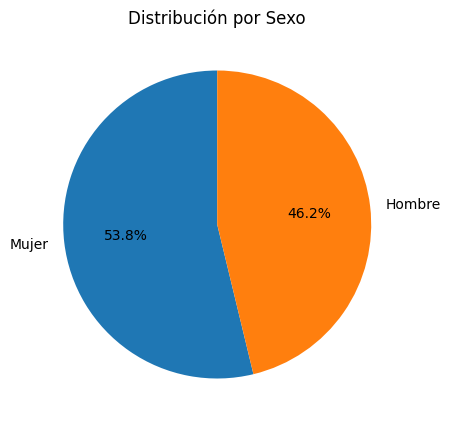

In [7]:
#VISUALIZACION DE LOS DATOS - #SEXO
df_inscripciones_final['SEXO'].replace({1:'Hombre', 2:'Mujer'}).value_counts().plot(
    kind='pie', autopct='%1.1f%%', startangle=90, figsize=(5,5)
)
plt.title("Distribución por Sexo")
plt.ylabel("")
plt.show()

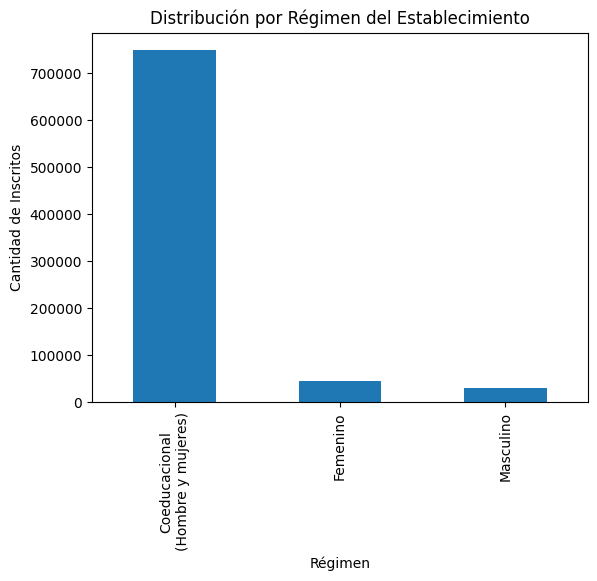

In [8]:
#VISUALIZACION DE LOS DATOS - REGIMEN
df_inscripciones_final['REGIMEN'].replace({1:'Masculino', 2:'Femenino', 3:'Coeducacional\n(Hombre y mujeres)'}).value_counts().plot(
    kind='bar'
)
plt.title("Distribución por Régimen del Establecimiento")
plt.xlabel("Régimen")
plt.ylabel("Cantidad de Inscritos")
plt.show()

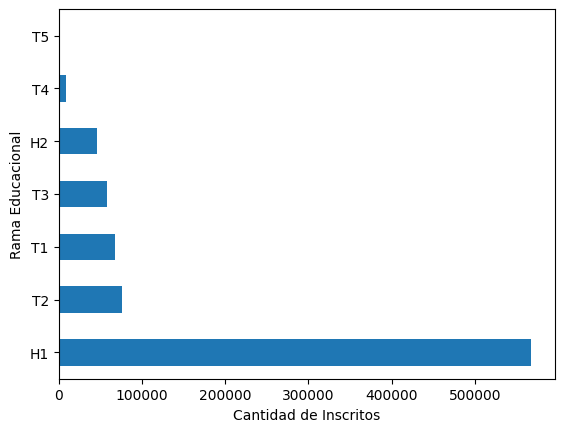

In [9]:
#VISUALIZACION DE LOS DATOS - RAMA_EDUCACIONAL

df_inscripciones_final['RAMA_EDUCACIONAL'].value_counts().plot(
    kind='barh'
)
plt.xlabel("Cantidad de Inscritos")
plt.ylabel("Rama Educacional")
plt.show()

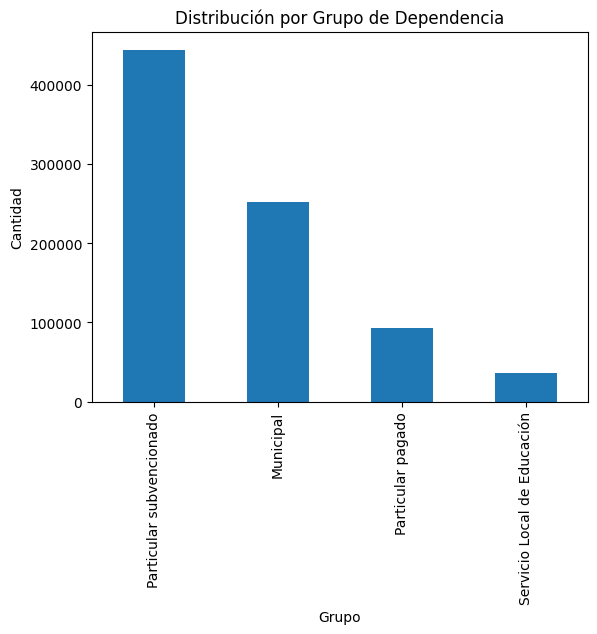

In [10]:
#VISUALIZACION DE LOS DATOS - GRUPO_DEPENDENCIA
df_inscripciones_final['GRUPO_DEPENDENCIA'].replace({
    1:'Particular pagado', 2:'Particular subvencionado', 
    3:'Municipal', 4:'Servicio Local de Educación'
}).value_counts().plot(kind='bar')
plt.title("Distribución por Grupo de Dependencia")
plt.xlabel("Grupo")
plt.ylabel("Cantidad")
plt.show()

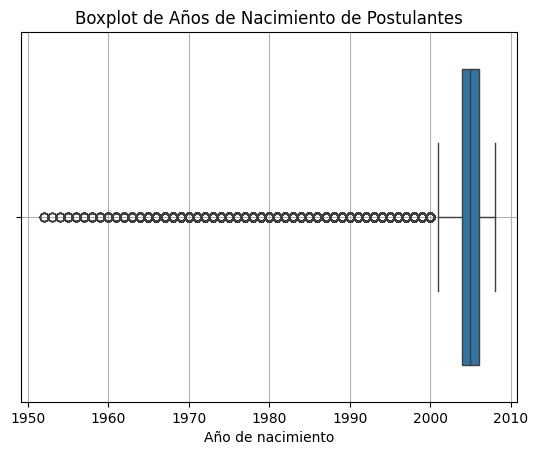

In [ ]:
#VISUALIZACION DE LOS DATOS - EDAD

df_inscripciones_final['ANYO_NACIMIENTO'] = df_inscripciones_final['FECHA_NACIMIENTO'].dt.year
sns.boxplot(x=df_inscripciones_final['ANYO_NACIMIENTO'])
plt.title("Boxplot de Años de Nacimiento de Postulantes")
plt.xlabel("Año de nacimiento")
plt.grid(True)
plt.show()

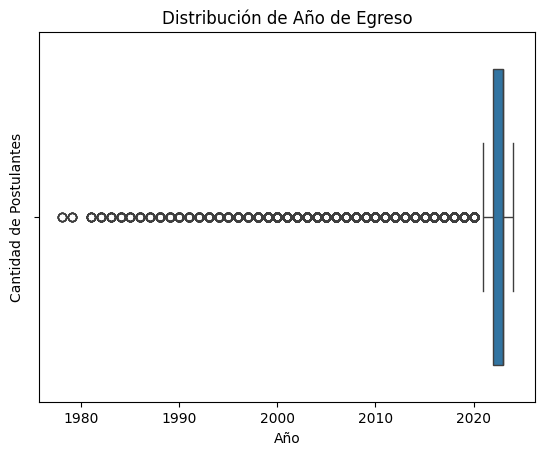

In [14]:
#VISUALIZACION DE LOS DATOS - ANYO_EGRESO
sns.boxplot(x=df_inscripciones_final['ANYO_EGRESO'])
plt.title("Distribución de Año de Egreso")
plt.xlabel("Año")
plt.ylabel("Cantidad de Postulantes")
plt.show()

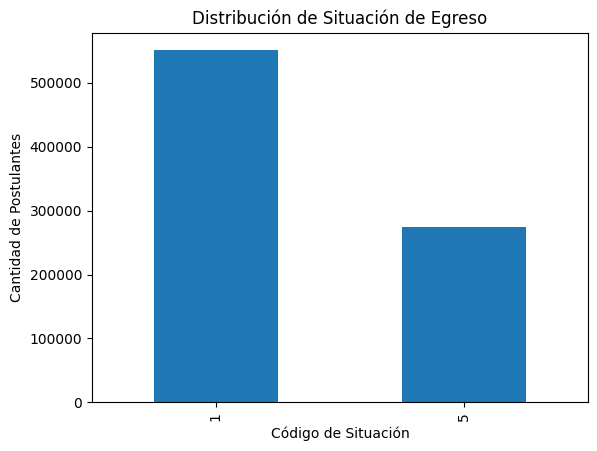

In [16]:
#VISUALIZACION DE LOS DATOS - SITUACION_EGRESO
df_inscripciones_final['SITUACION_EGRESO'].value_counts().plot(kind='bar')
plt.title("Distribución de Situación de Egreso")
plt.xlabel("Código de Situación")
plt.ylabel("Cantidad de Postulantes")
plt.show()

Text(0, 0.5, 'Cantidad')

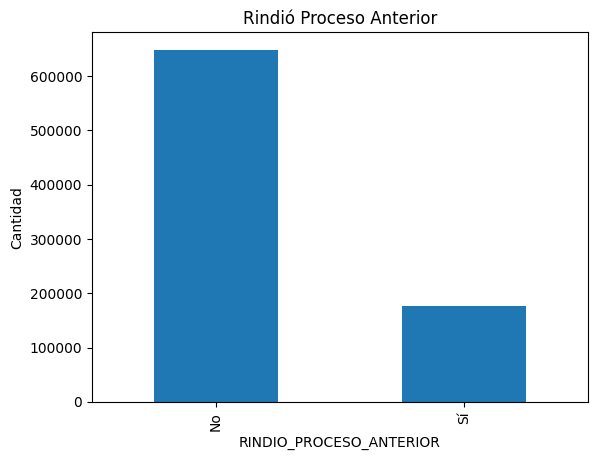

In [ ]:
#VISUALIZACION DE LOS DATOS - RINDIO_PROCESO_ANTERIOR y RINDIO_PROCESO_ACTUAL

df_inscripciones_final['RINDIO_PROCESO_ANTERIOR'].replace({0:'No', 1:'Sí'}).value_counts().plot(
    kind='bar')
plt.title("Rindió Proceso Anterior")
plt.ylabel("Cantidad")


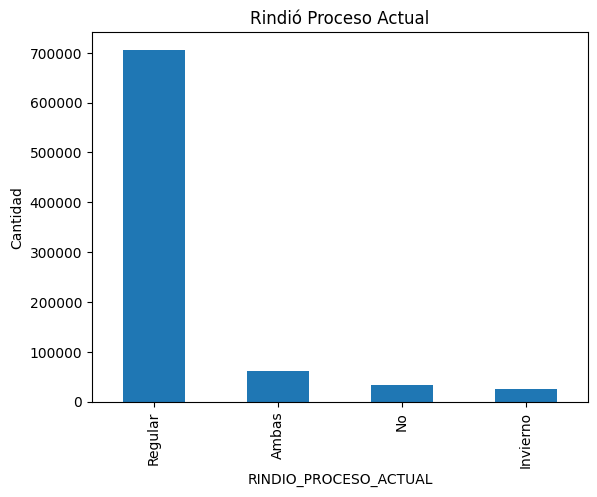

In [54]:
df_inscripciones_final['RINDIO_PROCESO_ACTUAL'].replace({0:'No',1:'Regular',2:'Invierno',3:'Ambas'}).value_counts().plot(
    kind='bar')
plt.title("Rindió Proceso Actual")
plt.ylabel("Cantidad")
plt.show()

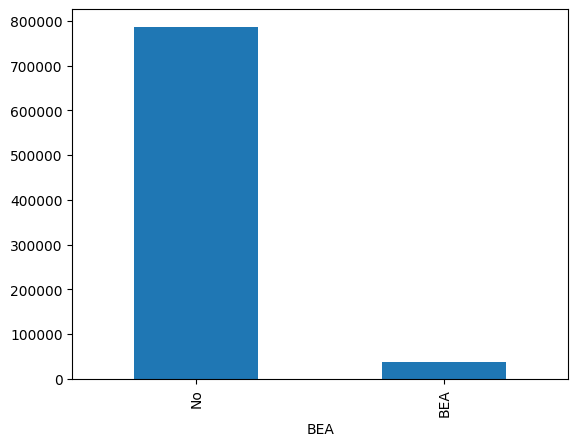

In [ ]:
#VISUALIZACION DE LOS DATOS - BEA
df_inscripciones_final['BEA'].replace({0:'No', 1:'Sí'}).value_counts().plot(kind='bar')
axes[0].set_title("Beneficiarios BEA")
axes[0].set_ylabel("Cantidad")
plt.show()

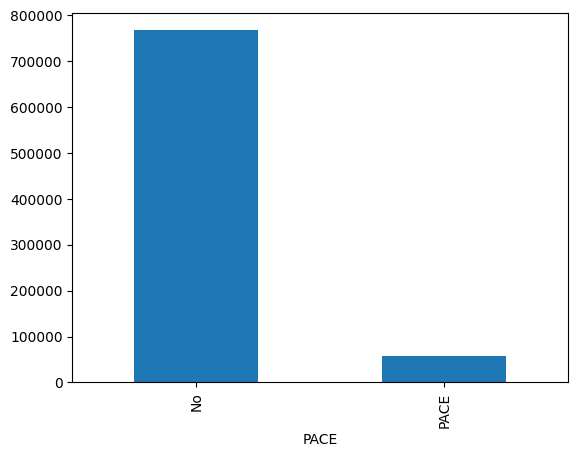

In [45]:
#VISUALIZACION DE LOS DATOS - PACE
df_inscripciones_final['PACE'].replace({0:'No', 1:'Sí'}).value_counts().plot(kind='bar')
axes[1].set_title("Beneficiarios PACE")
axes[1].set_ylabel("Cantidad")
plt.show()

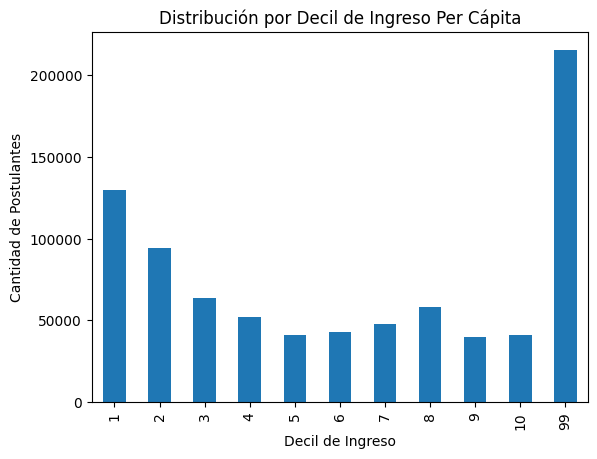

In [47]:
#VISUALIZACION DE LOS DATOS - INGRESO_PERCAPITA_GRUPO_FA
df_inscripciones_final['INGRESO_PERCAPITA_GRUPO_FA'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribución por Decil de Ingreso Per Cápita")
plt.xlabel("Decil de Ingreso")
plt.ylabel("Cantidad de Postulantes")
plt.show()

------------------------------------------------------------------------------------------------------------------------